<div align="center">

# PROYECTO FINAL
## **Dataset de Películas**

### Minería de Datos  



**Fuente:** Hugging Face – TMDB Movies Dataset



**Integrantes**  
Juan Daniel Ramirez Mojica

Maria Paula Carvajal Martinez


Paula Daniela Guzman Zabala

Karem Nataly Sierra Molina




**Universidad**  
Universidad Nacional de Colombia


**Fecha**  
25/02/2026  

</div>


##**1. Comprensión del problema y del dataset**

Fuente del Dataset:

[1] Datadruids, “Full TMDB Movies Dataset,” HuggingFace.co, 2026. Available: https://huggingface.co/datasets/ada-datadruids/full_tmdb_movies_dataset. [Accessed: Feb. 24, 2026]


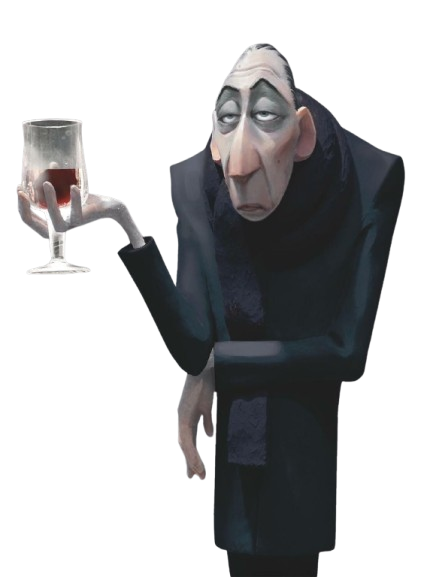

##  ¿Qué estamos analizando?

- El cine es una de las industrias culturales más grandes del mundo, con millones de títulos producidos a lo largo de la historia en decenas de idiomas y géneros.
- En este proyecto se analiza un conjunto de datos masivo con información de películas extraída de bases de datos como TMDB (The Movie Database).
- El dataset contiene 1,142,342 registros de películas (filas) y 24 variables (columnas) que describen características como título, géneros, popularidad, presupuesto, recaudación, sinopsis y palabras clave.
- Se incluyen tanto variables numéricas (votos, ingresos, duración, popularidad) como variables de texto libre (sinopsis, géneros, keywords), lo que permite combinar técnicas de análisis estadístico con procesamiento de lenguaje natural (NLP).
- El objetivo principal es construir un sistema de recomendación de películas basado en......
- El análisis exploratorio busca comprender la distribución del catálogo, identificar patrones en géneros, épocas y popularidad y preparar los datos para .....

**Presentación (diapositivas)**: https://www.canva.com/design/DAHCP12ebtc/5khUpBy5Q0LfSIDzacsflA/edit

## **2. Inspección inicial de los datos**

### **2.1. Recolección de Datos Iniciales**


El conjunto de datos fue descargado directamente desde Hugging Face
 mediante la librería datasets, permitiendo una integración sencilla y reproducible en el entorno de análisis.

In [ ]:
#pip install datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

In [ ]:

# Cargar el dataset desde Hugging Face
dataset = load_dataset("ada-datadruids/full_tmdb_movies_dataset")

# Ver splits disponibles
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


TMDB_movie_dataset_v11.csv:   0%|          | 0.00/524M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1142342 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords'],
        num_rows: 1142342
    })
})


Cargamos el dataset

In [ ]:
# Convertir el split "train" a pandas
df = dataset["train"].to_pandas()

print(f"Se cargaron {len(df)} filas.")


Se cargaron 1142342 filas.


A continuación veremos archivos descargados, junto a la creación de la ruta correcta, y la carga de datos:

In [ ]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [ ]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1142337,741864,Criadores de Melodias - As Lendas do Rock,0.0,0,Released,None,0,0,False,None,...,Criadores de Melodias - As Lendas do Rock,None,0.600,/lZtb2L6E5e0MGBe3iMBl168A8fG.jpg,None,None,None,None,None,None
1142338,741865,Aprenda Trombone Gospel Básico,0.0,0,Released,None,0,0,False,None,...,Aprenda Trombone Gospel Básico,None,0.600,None,None,None,None,None,None,None
1142339,741866,Aprenda Violão Avançado,0.0,0,Released,None,0,0,False,None,...,Aprenda Violão Avançado,None,0.600,/itp1p8Ex8gdSiCcdHfgKcZbhAWw.jpg,None,None,None,None,None,None
1142340,72865,Our Big Sister,0.0,0,Released,1964-04-22,0,0,False,None,...,Our Big Sister,None,0.841,None,None,Drama,None,Hong Kong,Cantonese,None
1142341,1397642,I WANT MY MOMMY,0.0,0,Released,2025-01-31,0,19,False,/f1RJgdrusjuOWn4DJtZq1CtCgbh.jpg,...,I WANT MY MOMMY,"Mourning the death of his mother, a man is pre...",0.600,/uiZePWWCYmwSsydMzZe6OEpva1O.jpg,Mommy Loves You... No Matter What,"Drama, Comedy",Four Eyes Films,United States of America,English,None


## 2.2. Análisis de Calidad de Datos

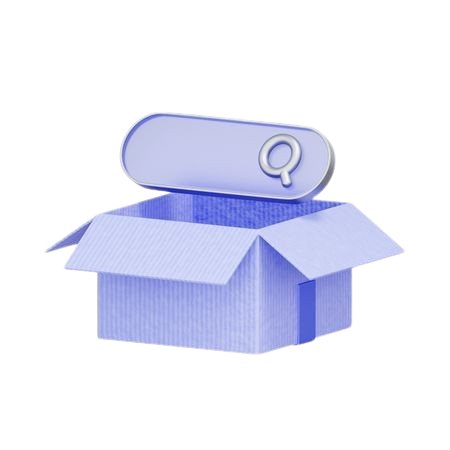

In [ ]:
df.shape

(1142342, 24)

**Información general de nuestro dataset:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1142342 entries, 0 to 1142341
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1142342 non-null  int64  
 1   title                 1142329 non-null  object 
 2   vote_average          1142342 non-null  float64
 3   vote_count            1142342 non-null  int64  
 4   status                1142342 non-null  object 
 5   release_date          953051 non-null   object 
 6   revenue               1142342 non-null  int64  
 7   runtime               1142342 non-null  int64  
 8   adult                 1142342 non-null  bool   
 9   backdrop_path         302739 non-null   object 
 10  budget                1142342 non-null  int64  
 11  homepage              120868 non-null   object 
 12  imdb_id               604127 non-null   object 
 13  original_language     1142342 non-null  object 
 14  original_title        1142329 non-

- Los tipos de datos incluyen 5 variables enteras, 2 flotantes, 1 booleana y 16 de tipo objeto (texto), lo que demanda preprocesamiento tanto numérico como de lenguaje natural para construir los embeddings.

**Revisamos los valores faltantes:**

In [ ]:
df.isnull().sum()

,0
id,0
title,13
vote_average,0
vote_count,0
status,0
release_date,189291
revenue,0
runtime,0
adult,0
backdrop_path,839603


- En cuanto a completitud de datos, columnas clave para el sistema de recomendación presentan valores nulos significativos: overview tiene ~232K nulos (20%), genres ~459K nulos (40%), y keywords ~833K nulos (73%) — estas columnas deberán tratarse antes del modelado semántico.

## **2.3. Descripción de los Datos**

In [ ]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.142342e+06,1.142342e+06,1.142342e+06,1.142342e+06,1.142342e+06,1.142342e+06,1.142342e+06
mean,7.438866e+05,1.871655e+00,1.877642e+01,6.886895e+05,4.766112e+01,2.672661e+05,1.231351e+00
std,3.975214e+05,3.017612e+00,3.177172e+02,1.790831e+07,6.165081e+01,5.062581e+06,7.568423e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.125922e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,7.489705e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01,0.000000e+00,6.000000e-01
75%,1.097095e+06,4.700000e+00,1.000000e+00,0.000000e+00,8.900000e+01,0.000000e+00,8.760000e-01
max,1.397836e+06,1.000000e+01,3.449500e+04,3.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03




- El dataset contiene 1,142,342 registros y 24 variables de producción, popularidad y metadata cinematográfica.
- La puntuación promedio (vote_average) de las películas es de apenas 1.87 sobre 10, lo cual refleja que la gran mayoría de títulos en el dataset tienen muy pocos o ningún voto — la mediana es 0, indicando que el 50% de las películas aún no han sido calificadas por usuarios.
- La duración promedio (runtime) ronda los 47 minutos, aunque con alta variabilidad: hay títulos con duración negativa o cero (datos a limpiar) y un máximo de 14,400 minutos, lo que sugiere la presencia de outliers importantes.

- El presupuesto y la recaudación presentan una distribución extremadamente sesgada: la mediana de ambos es 0, lo que indica que la mayoría de películas no tiene datos financieros registrados, mientras que unos pocos blockbusters concentran valores de hasta 3,000 millones en recaudación.
- La popularidad promedio es de 1.23, pero con una desviación estándar de 7.57 y un máximo de ~2,994, lo que evidencia que unas pocas películas concentran casi toda la atención, siguiendo una distribución de tipo ley de potencia (power law).

## **3. Exploración de Datos (Análisis Estadístico)**

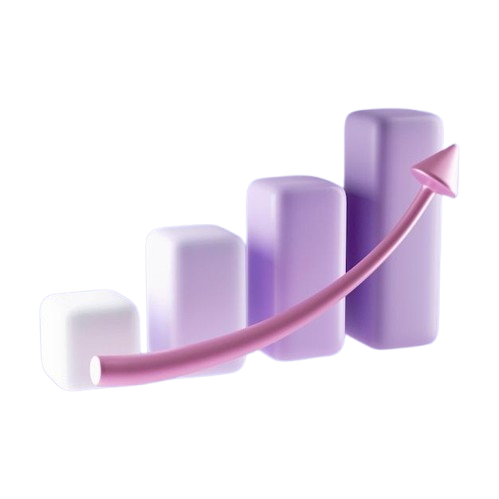

¿Qué representa cada medida que estamos obteniendo en el siguiente código?

| Medida              | Qué significa                    | Para que sirve                |
| ------------------- | -------------------------------- | ----------------------------- |
| **Media**           | Promedio                         | Valor típico general          |
| **Mediana (Q2)**    | Valor central                    | Evita sesgos por extremos     |
| **Moda**            | Valor más repetido               | Detecta valores dominantes    |
| **Desv. Std**       | Qué tanto se dispersan los datos | Variabilidad                  |
| **Varianza**        | Dispersión al cuadrado           | Confirmar variabilidad        |
| **Mínimo / Máximo** | Valores extremos                 | Rango real                    |
| **Q1 / Q3**         | 25% y 75%                        | Dónde se concentra la mayoría |
| **Rango**           | Máx - mín                        | Amplitud total                |


En esta sección se analizan las principales características estadísticas del conjunto de datos, con el fin de comprender la distribución de las variables, identificar valores atípicos y observar tendencias generales en la información de los pacientes.

In [ ]:
import pandas as pd

"""
Variables numéricas continuas a analizar
"""

variables = [
    "vote_average",   # Puntuación promedio de la película
    "vote_count",     # Número de votos recibidos
    "revenue",        # Recaudación en taquilla
    "runtime",        # Duración en minutos
    "budget",         # Presupuesto de producción
    "popularity"      # Índice de popularidad TMDB
]


def resumen_estadistico(df, columnas):
    resumen = pd.DataFrame({
        "Media": df[columnas].mean(),
        "Mediana": df[columnas].median(),
        "Moda": df[columnas].mode().iloc[0],
        "Desv. Std": df[columnas].std(),
        "Varianza": df[columnas].var(),
        "Mínimo": df[columnas].min(),
        "Q1 (25%)": df[columnas].quantile(0.25),
        "Q2 (50%)": df[columnas].quantile(0.50),
        "Q3 (75%)": df[columnas].quantile(0.75),
        "Máximo": df[columnas].max(),
        "Rango": df[columnas].max() - df[columnas].min()
    })

    return resumen.round(2)


resumen = resumen_estadistico(df, variables)

resumen

,Media,Mediana,Moda,Desv. Std,Varianza,Mínimo,Q1 (25%),Q2 (50%),Q3 (75%),Máximo,Rango
vote_average,1.87,0.0,0.0,3.02,9.110000e+00,0.0,0.0,0.0,4.70,1.000000e+01,1.000000e+01
vote_count,18.78,0.0,0.0,317.72,1.009442e+05,0.0,0.0,0.0,1.00,3.449500e+04,3.449500e+04
revenue,688689.48,0.0,0.0,17908310.80,3.207076e+14,-12.0,0.0,0.0,0.00,3.000000e+09,3.000000e+09
runtime,47.66,22.0,0.0,61.65,3.800820e+03,-28.0,0.0,22.0,89.00,1.440000e+04,1.442800e+04
budget,267266.15,0.0,0.0,5062581.18,2.562973e+13,0.0,0.0,0.0,0.00,1.000000e+09,1.000000e+09
popularity,1.23,0.6,0.6,7.57,5.728000e+01,0.0,0.6,0.6,0.88,2.994360e+03,2.994360e+03


¿Qué podemos interpretar de estas medidas obtenidas?

### Interpretación del resumen estadístico

- **Puntuación promedio (vote_average):**
  - La media es de 1.87 sobre 10, pero la mediana es 0, lo que indica que más del 50% de las películas no tienen ninguna calificación registrada.
  - El grupo de películas efectivamente valoradas tiende a concentrarse entre 4.7 y 10, sugiriendo que cuando hay votos, la calidad percibida es moderada-alta.

- **Número de votos (vote_count):**
  - Promedio de ~19 votos por película, pero con mediana 0, confirmando que la mayoría de títulos son prácticamente desconocidos o sin interacción de usuarios.
  - Unos pocos blockbusters concentran hasta 34,495 votos, generando una distribución extremadamente sesgada a la derecha.

- **Recaudación (revenue):**
  - La mediana es \$0, lo que refleja que la gran mayoría de películas no tiene datos de taquilla registrados, no necesariamente que no recaudaron nada.
  - Se detectan valores negativos (-12) que corresponden a errores de datos a corregir, y un máximo de \$3,000 millones perteneciente a un grupo muy reducido de superproducciones.

- **Duración (runtime):**
  - Promedio de ~47 minutos con mediana de 22 minutos, lo que sugiere que el dataset incluye una gran cantidad de cortometrajes además de largometrajes.
  - Se detectan valores negativos (-28 minutos) y un máximo de 14,400 minutos, ambos outliers claros que requieren limpieza.

- **Presupuesto (budget):**
  - La mediana es \$0, indicando ausencia masiva de datos financieros en el catálogo general.
  - Solo una fracción pequeña de producciones tiene presupuestos registrados, con un máximo de \$1,000 millones.

- **Popularidad (popularity):**
  - La mediana es 0.6 y el 75% de las películas no supera 0.88, mostrando que la gran mayoría son títulos de nicho o poco conocidos.
  - El máximo de ~2,994 corresponde a fenómenos culturales masivos, siguiendo una distribución tipo ley de potencia típica en consumo cultural.

### Conclusión general
El dataset refleja la realidad de la industria cinematográfica global: un catálogo masivo dominado por producciones pequeñas, independientes o sin datos completos, donde un grupo reducido de grandes producciones concentra casi toda la popularidad, recaudación y atención del público. Esto implica que antes de construir el sistema de recomendación será fundamental filtrar y limpiar el dataset, priorizando películas con sinopsis disponible, al menos algunos votos registrados y duración coherente.


In [ ]:
resumen.style.background_gradient(cmap="Blues")


,Media,Mediana,Moda,Desv. Std,Varianza,Mínimo,Q1 (25%),Q2 (50%),Q3 (75%),Máximo,Rango
vote_average,1.870000,0.000000,0.000000,3.020000,9.110000,0.000000,0.000000,0.000000,4.700000,10.000000,10.000000
vote_count,18.780000,0.000000,0.000000,317.720000,100944.190000,0.000000,0.000000,0.000000,1.000000,34495.000000,34495.000000
revenue,688689.480000,0.000000,0.000000,17908310.800000,320707595758460.125000,-12.000000,0.000000,0.000000,0.000000,3000000000.000000,3000000012.000000
runtime,47.660000,22.000000,0.000000,61.650000,3800.820000,-28.000000,0.000000,22.000000,89.000000,14400.000000,14428.000000
budget,267266.150000,0.000000,0.000000,5062581.180000,25629728223859.621094,0.000000,0.000000,0.000000,0.000000,999999999.000000,999999999.000000
popularity,1.230000,0.600000,0.600000,7.570000,57.280000,0.000000,0.600000,0.600000,0.880000,2994.360000,2994.360000


Se utilizó un mapa de calor (heatmap) para visualizar de forma intuitiva las principales estadísticas descriptivas de las variables numéricas.
La intensidad del color representa la magnitud de cada medida, permitiendo identificar rápidamente diferencias en dispersión, rangos de valores y tendencias generales entre las variables analizadas.

A partir del mapa de calor se observa que variables como revenue, budget, vote_count y popularity presentan una alta dispersión y rangos extremadamente amplios, lo que sugiere distribuciones fuertemente asimétricas hacia la derecha y la presencia de valores atípicos (outliers). Esto se confirma al notar que sus medianas y primeros cuartiles son iguales a cero, mientras que sus medias son considerablemente superiores, indicando que unos pocos valores extremos influyen de manera importante en la tendencia central.

## **3.2. Estadísticas Multivariadas**

In [ ]:
import pandas as pd

"""
Estadísticas Multivariadas
"""

variables = [
    "vote_average",
    "vote_count",
    "revenue",
    "runtime",
    "budget",
    "popularity"
]


def matriz_covarianza(df, columnas):
    """
    Matriz de covarianza entre variables numéricas
    """
    return df[columnas].cov().round(2)


def matriz_correlacion(df, columnas):
    """
    Matriz de correlación entre variables numéricas
    """
    return df[columnas].corr().round(2)


covarianza = matriz_covarianza(df, variables)
correlacion = matriz_correlacion(df, variables)

print("MATRIZ DE COVARIANZA\n")
covarianza

MATRIZ DE COVARIANZA



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,9.11,9.308000e+01,3.080976e+06,42.59,1.051456e+06,2.72
vote_count,93.08,1.009442e+05,3.949708e+09,1173.62,9.117200e+08,610.95
revenue,3080976.17,3.949708e+09,3.207076e+14,45824727.51,5.807766e+13,30603104.54
runtime,42.59,1.173620e+03,4.582473e+07,3800.82,1.685748e+07,32.83
budget,1051455.68,9.117200e+08,5.807766e+13,16857482.83,2.562973e+13,9145858.30
popularity,2.72,6.109500e+02,3.060310e+07,32.83,9.145858e+06,57.28


In [ ]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlacion


MATRIZ DE CORRELACIÓN 



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


La correlación más fuerte se da entre revenue y vote_count (0.69), seguida de budget y revenue (0.64) y budget y vote_count (0.57), lo que tiene sentido: las películas con mayor presupuesto tienden a recaudar más y a recibir más votos, al ser producciones de mayor distribución y visibilidad.

Popularity muestra correlaciones moderadas con vote_count (0.25), budget (0.24) y revenue (0.23), confirmando que las películas más taquilleras también son las más populares en la plataforma.


Por otro lado, vote_average presenta correlaciones muy bajas con todas las demás variables (máximo 0.23 con runtime), lo que indica que la calidad percibida por los usuarios es independiente del presupuesto, la recaudación o la popularidad — una película puede ser muy bien valorada sin ser un éxito comercial.


La covarianza refleja las mismas tendencias pero amplificada por las diferencias de escala entre variables: revenue y budget dominan numéricamente por sus magnitudes en miles de millones, lo que no implica mayor correlación sino simplemente unidades más grandes.


En general, el dataset muestra que el éxito comercial y la popularidad van de la mano, pero la calidad cinematográfica sigue su propio camino independiente.

In [ ]:
df.describe(include='all')

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
count,1.142342e+06,1142329,1.142342e+06,1.142342e+06,1142342,953051,1.142342e+06,1.142342e+06,1142342,302739,...,1142329,909559,1.142342e+06,780713,160131,683632,514838,635094,654522,308817
unique,NaN,979567,NaN,NaN,6,42753,NaN,NaN,2,300190,...,1013442,883954,NaN,776153,153926,13362,206431,10084,7063,177129
top,NaN,Home,NaN,NaN,Released,2006-01-01,NaN,NaN,False,/3CxwYgqGtJ6UEGfWUT0gMYCIlFP.jpg,...,Untitled,,NaN,/wtoKLMm4UvkwvcSwO3XWcs1gJuF.jpg,English,Documentary,Evil Angel,United States of America,English,short film
freq,NaN,157,NaN,NaN,1115961,3580,NaN,NaN,1035796,157,...,108,1130,NaN,54,214,135585,2922,178417,233903,10389
mean,7.438866e+05,NaN,1.871655e+00,1.877642e+01,NaN,NaN,6.886895e+05,4.766112e+01,NaN,NaN,...,NaN,NaN,1.231351e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.975214e+05,NaN,3.017612e+00,3.177172e+02,NaN,NaN,1.790831e+07,6.165081e+01,NaN,NaN,...,NaN,NaN,7.568423e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,-1.200000e+01,-2.800000e+01,NaN,NaN,...,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.125922e+05,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,...,NaN,NaN,6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.489705e+05,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,2.200000e+01,NaN,NaN,...,NaN,NaN,6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.097095e+06,NaN,4.700000e+00,1.000000e+00,NaN,NaN,0.000000e+00,8.900000e+01,NaN,NaN,...,NaN,NaN,8.760000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **4. Gráficas**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


## **4.1 Histogramas**

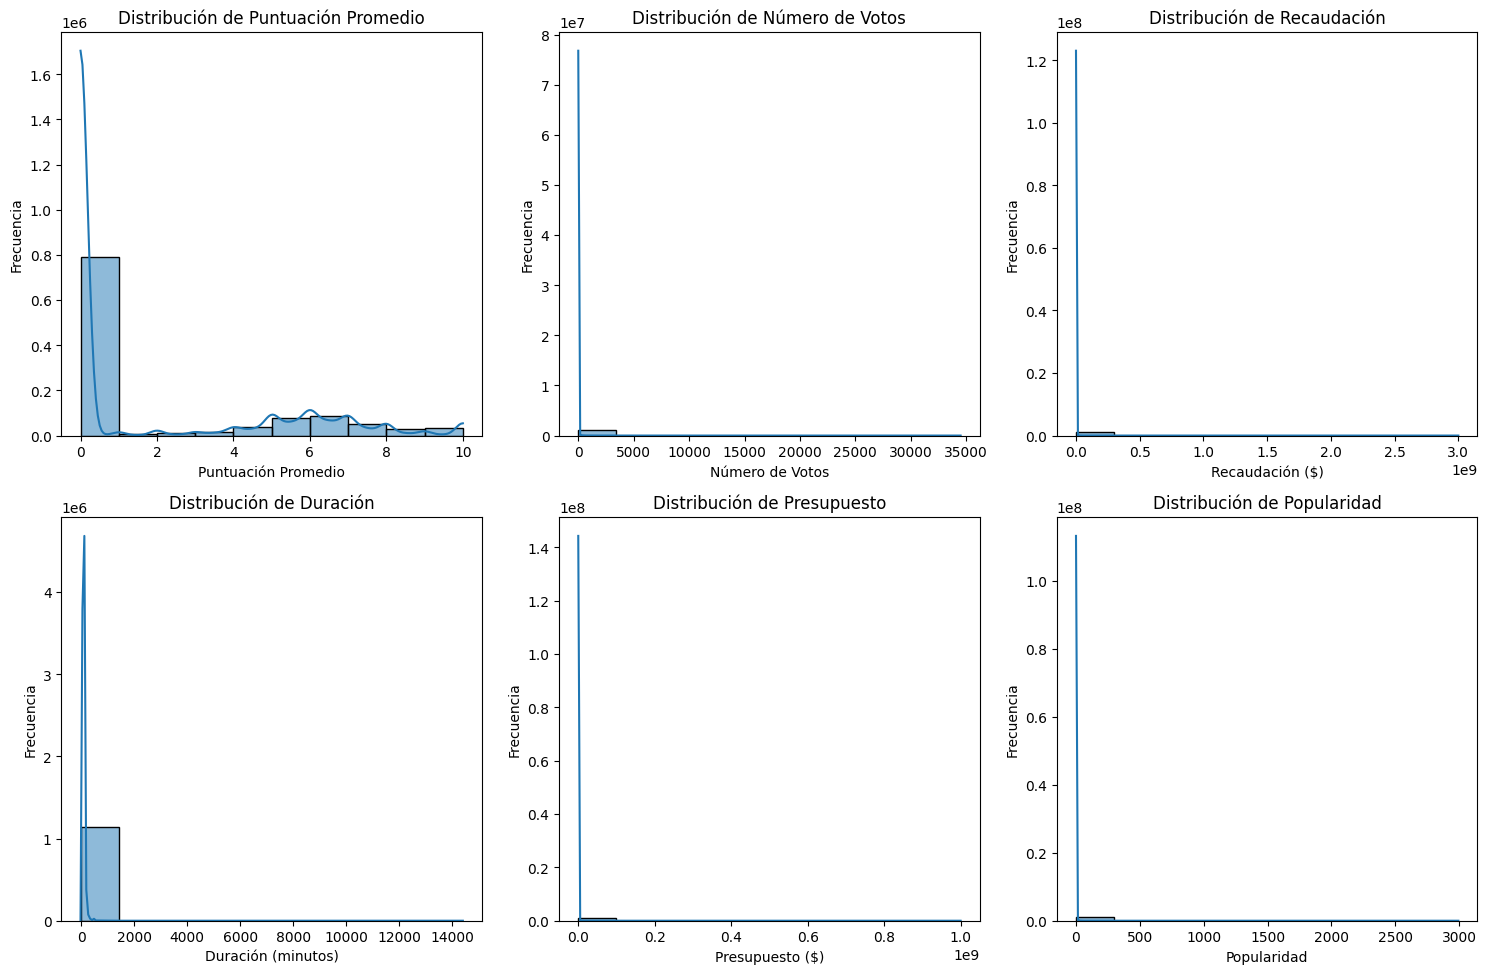

In [ ]:
plt.figure(figsize=(15, 10))

# Histogram for vote_average
plt.subplot(2, 3, 1)
sns.histplot(df['vote_average'], kde=True, bins=10)
plt.title('Distribución de Puntuación Promedio')
plt.xlabel('Puntuación Promedio')
plt.ylabel('Frecuencia')

# Histogram for vote_count
plt.subplot(2, 3, 2)
sns.histplot(df['vote_count'], kde=True, bins=10)
plt.title('Distribución de Número de Votos')
plt.xlabel('Número de Votos')
plt.ylabel('Frecuencia')

# Histogram for revenue
plt.subplot(2, 3, 3)
sns.histplot(df['revenue'], kde=True, bins=10)
plt.title('Distribución de Recaudación')
plt.xlabel('Recaudación ($)')
plt.ylabel('Frecuencia')

# Histogram for runtime
plt.subplot(2, 3, 4)
sns.histplot(df['runtime'], kde=True, bins=10)
plt.title('Distribución de Duración')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

# Histogram for budget
plt.subplot(2, 3, 5)
sns.histplot(df['budget'], kde=True, bins=10)
plt.title('Distribución de Presupuesto')
plt.xlabel('Presupuesto ($)')
plt.ylabel('Frecuencia')

# Histogram for popularity
plt.subplot(2, 3, 6)
sns.histplot(df['popularity'], kde=True, bins=10)
plt.title('Distribución de Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación de los histogramas

Al visualizar las distribuciones con todos los datos del dataset original, se observa un patrón común en todas las variables: **una barra dominante en el valor 0 que aplasta completamente el resto de la distribución**, haciendo imposible analizar el comportamiento real de los datos. Esto se debe a que la gran mayoría de películas en el dataset no tienen datos financieros registrados (presupuesto y recaudación en 0), no han recibido votos (vote_average y vote_count en 0), o tienen duración y popularidad sin registrar.

Adicionalmente, en **Duración** se detectan outliers extremos de hasta 14,400 minutos (~10 días), valores claramente erróneos que distorsionan el eje horizontal. En **Recaudación** y **Presupuesto** también aparecen valores negativos que no tienen sentido económico.

Para poder analizar la distribución real de las películas con información completa, se filtraron los registros eliminando los ceros en todas las variables y limitando la duración a un máximo de 300 minutos (5 horas).

Películas con datos completos: 10,362 de 1,142,342 (0.9%)


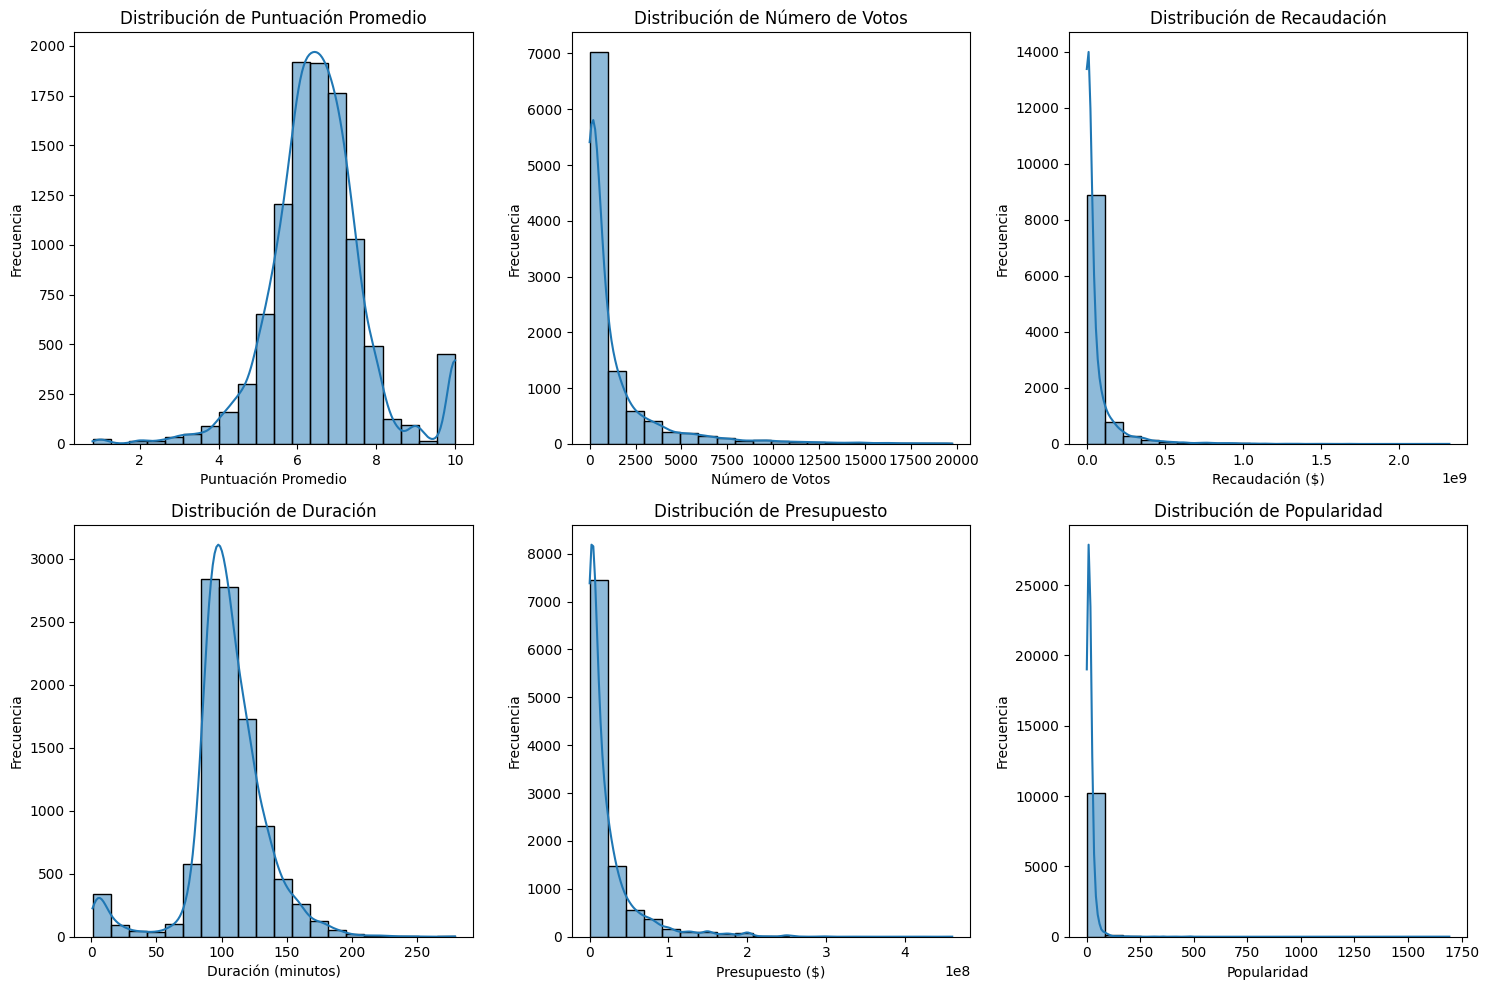

In [ ]:
plt.figure(figsize=(15, 10))

# Filtrar ceros y outliers solo para visualización
df_viz = df[
    (df['vote_average'] > 0) &
    (df['vote_count'] > 0) & (df['vote_count'] <= 20000) &
    (df['revenue'] > 0) &
    (df['runtime'] > 0) & (df['runtime'] <= 300) &  # máximo 5 horas
    (df['budget'] > 0) &
    (df['popularity'] > 0) & (df['popularity'] <= 2000)
]

print(f"Películas con datos completos: {len(df_viz):,} de {len(df):,} ({len(df_viz)/len(df)*100:.1f}%)")

# Histogram for vote_average
plt.subplot(2, 3, 1)
sns.histplot(df_viz['vote_average'], kde=True, bins=20)
plt.title('Distribución de Puntuación Promedio')
plt.xlabel('Puntuación Promedio')
plt.ylabel('Frecuencia')

# Histogram for vote_count
plt.subplot(2, 3, 2)
sns.histplot(df_viz['vote_count'], kde=True, bins=20)
plt.title('Distribución de Número de Votos')
plt.xlabel('Número de Votos')
plt.ylabel('Frecuencia')

# Histogram for revenue
plt.subplot(2, 3, 3)
sns.histplot(df_viz['revenue'], kde=True, bins=20)
plt.title('Distribución de Recaudación')
plt.xlabel('Recaudación ($)')
plt.ylabel('Frecuencia')

# Histogram for runtime
plt.subplot(2, 3, 4)
sns.histplot(df_viz['runtime'], kde=True, bins=20)
plt.title('Distribución de Duración')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

# Histogram for budget
plt.subplot(2, 3, 5)
sns.histplot(df_viz['budget'], kde=True, bins=20)
plt.title('Distribución de Presupuesto')
plt.xlabel('Presupuesto ($)')
plt.ylabel('Frecuencia')

# Histogram for popularity
plt.subplot(2, 3, 6)
sns.histplot(df_viz['popularity'], kde=True, bins=20)
plt.title('Distribución de Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

A continuación se presentan los histogramas del subconjunto resultante:

- **Puntuación Promedio** — Se espera una distribución concentrada entre 5 y 8, típica de películas con suficientes votos para estabilizar su calificación.
- **Número de Votos** — Distribución fuertemente sesgada a la derecha: la mayoría de películas tiene pocos votos y solo unas pocas superan los miles.
- **Recaudación** — Sesgo extremo a la derecha, con la mayoría de películas recaudando poco y un grupo reducido de blockbusters concentrando los valores más altos.
- **Duración** — Se espera una concentración entre 80 y 120 minutos, rango típico del largometraje comercial.
- **Presupuesto** — Similar a recaudación, con fuerte sesgo a la derecha y pocos títulos con presupuestos muy elevados.
- **Popularidad** — Distribución tipo ley de potencia: la mayoría de películas tiene popularidad baja y solo unos pocos títulos concentran valores muy altos.

###**Valores únicos de variables categóricas:**

**Status:**

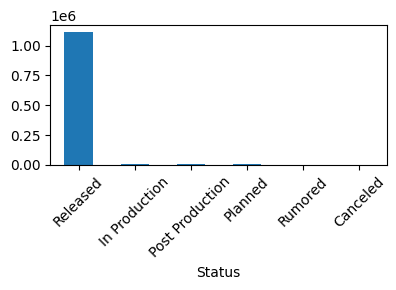

In [ ]:
plt.figure(figsize=(4, 3))
df["status"].value_counts(dropna=False).plot(kind="bar")
plt.xlabel('Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Adult:**

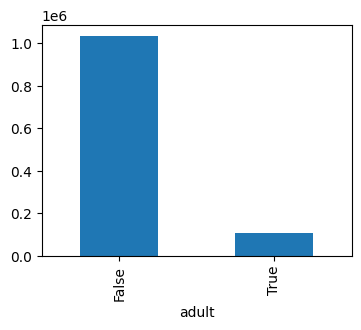

In [ ]:
plt.figure(figsize=(4, 3))
df["adult"].value_counts(dropna=False).plot(kind="bar")
plt.show()

**Original language:**

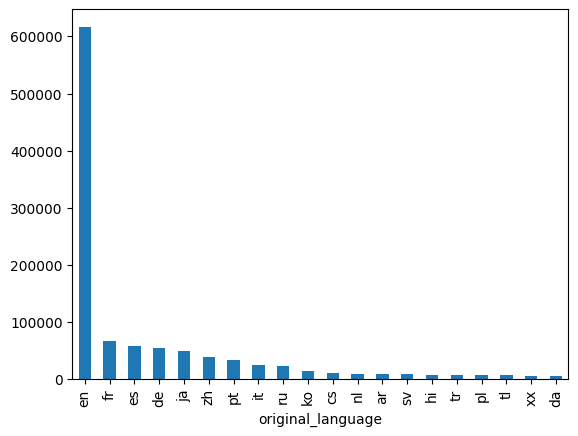

In [ ]:
df["original_language"].value_counts().head(20).plot(kind="bar")
plt.show()

## **4.2 Estimación de densidad**


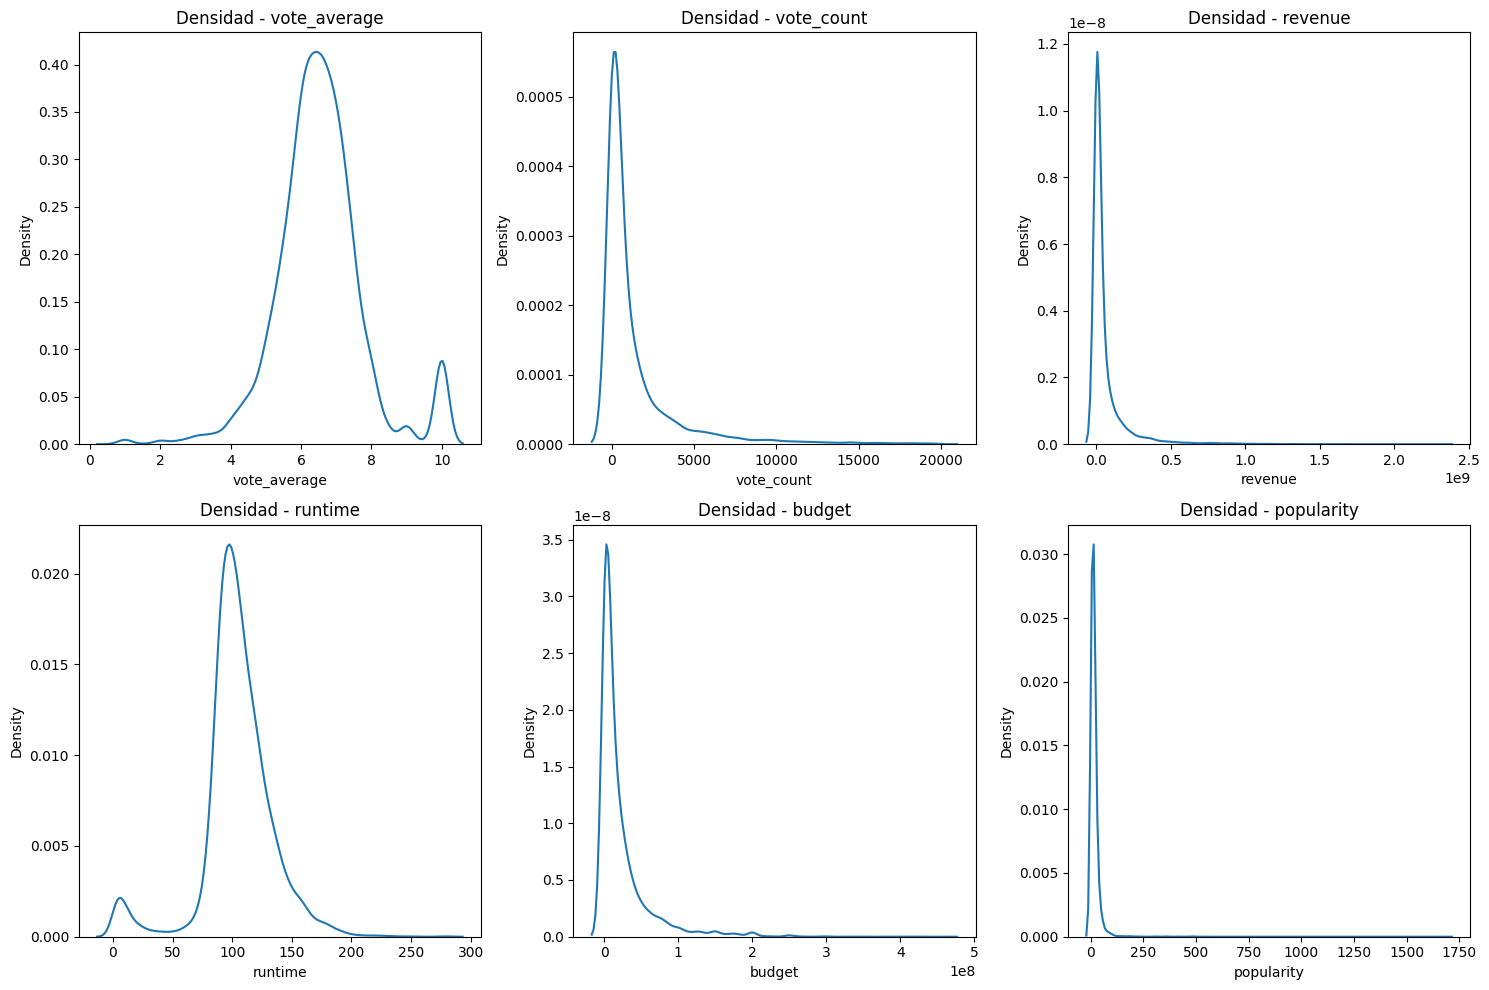

In [ ]:
plt.figure(figsize=(15, 10))

variables = ['vote_average', 'vote_count', 'revenue',
             'runtime', 'budget', 'popularity']

for i, var in enumerate(variables):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(df_viz[var], fill=False)
    plt.title(f'Densidad - {var}')

plt.tight_layout()
plt.show()

**vote_average** es la variable más cercana a una distribución normal dentro del conjunto seguida de **runtime**

Las demás variables requieren una transformación logaritmica al tener una distribución altamente sesgada (heavy-tailed)


## **4.3 Diagrama Boxplot**

<Axes: >

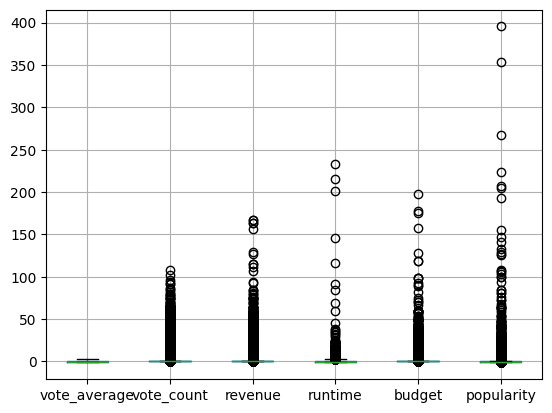

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = [
    "vote_average",   # Puntuación promedio de la película
    "vote_count",     # Número de votos recibidos
    "revenue",        # Recaudación en taquilla
    "runtime",        # Duración en minutos
    "budget",         # Presupuesto de producción
    "popularity"      # Índice de popularidad TMDB
]

scaled = StandardScaler().fit_transform(df[numerical_cols]) #Escalamos los datos
pd.DataFrame(scaled, columns=numerical_cols).boxplot()

Los diagramas de caja muestran distribuciones muy asimétricas con una presencia importante de outliers en las variables financieras de revenue y budget, además de la popularidad pero parece que es debido a fenónemos de la industria cinematográfica donde pocas producciones concentrar la mayor parte de la recaudación y la inversión.

## **4.4 Diagramas de dispersión**

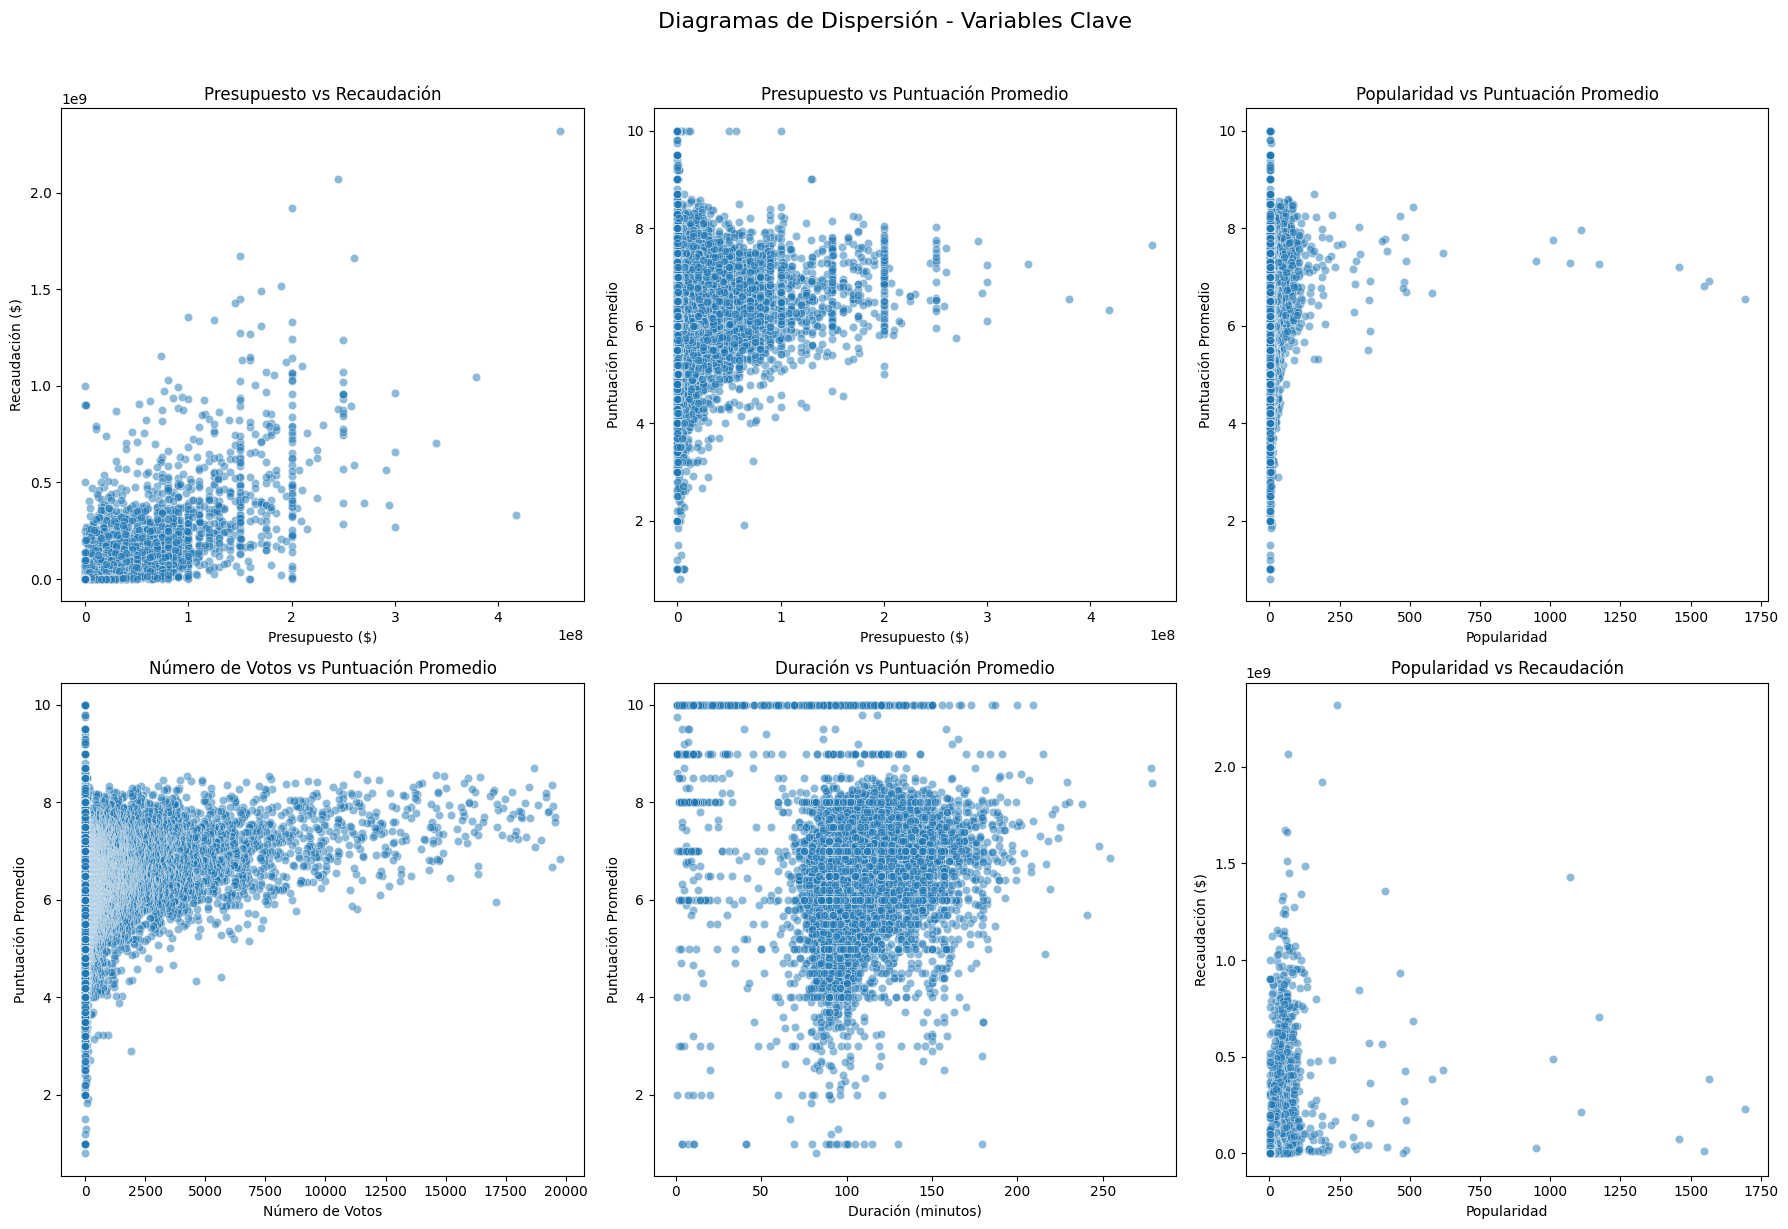

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Budget vs Revenue
sns.scatterplot(x='budget', y='revenue', data=df_viz, alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title('Presupuesto vs Recaudación')
axes[0, 0].set_xlabel('Presupuesto ($)')
axes[0, 0].set_ylabel('Recaudación ($)')

# Budget vs vote_average
sns.scatterplot(x='budget', y='vote_average', data=df_viz, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Presupuesto vs Puntuación Promedio')
axes[0, 1].set_xlabel('Presupuesto ($)')
axes[0, 1].set_ylabel('Puntuación Promedio')

# Popularity vs vote_average
sns.scatterplot(x='popularity', y='vote_average', data=df_viz, alpha=0.5, ax=axes[0, 2])
axes[0, 2].set_title('Popularidad vs Puntuación Promedio')
axes[0, 2].set_xlabel('Popularidad')
axes[0, 2].set_ylabel('Puntuación Promedio')

# vote_count vs vote_average
sns.scatterplot(x='vote_count', y='vote_average', data=df_viz, alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Número de Votos vs Puntuación Promedio')
axes[1, 0].set_xlabel('Número de Votos')
axes[1, 0].set_ylabel('Puntuación Promedio')

# runtime vs vote_average
sns.scatterplot(x='runtime', y='vote_average', data=df_viz, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Duración vs Puntuación Promedio')
axes[1, 1].set_xlabel('Duración (minutos)')
axes[1, 1].set_ylabel('Puntuación Promedio')

# popularity vs revenue
sns.scatterplot(x='popularity', y='revenue', data=df_viz, alpha=0.5, ax=axes[1, 2])
axes[1, 2].set_title('Popularidad vs Recaudación')
axes[1, 2].set_xlabel('Popularidad')
axes[1, 2].set_ylabel('Recaudación ($)')

plt.suptitle('Diagramas de Dispersión - Variables Clave', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Es posible confirmar visualmente las  relaciones que antes se habian encontrado al calcular las correlaciones entre estas variables.

- Presupuesto vs Recaudación: Relación positiva pero mucha dispersión

- Presupuesto vs Puntuación Promedio: No hay una relación muy fuerte, es decir, las películas caras no necesariamente tienen mejor rating.

- Número de Votos vs Puntuación Promedio: Parece que a mayor cantidad de votos el promedio se vuelve más estable.

- Duración vs Puntuación Promedio: La relación es demasiado débil

- Popularidad vs Recaudación: Existe una relación positiva pero es muy ruidosa.

(Revisar esas lineas)

Cogemos 6 películas al azar:

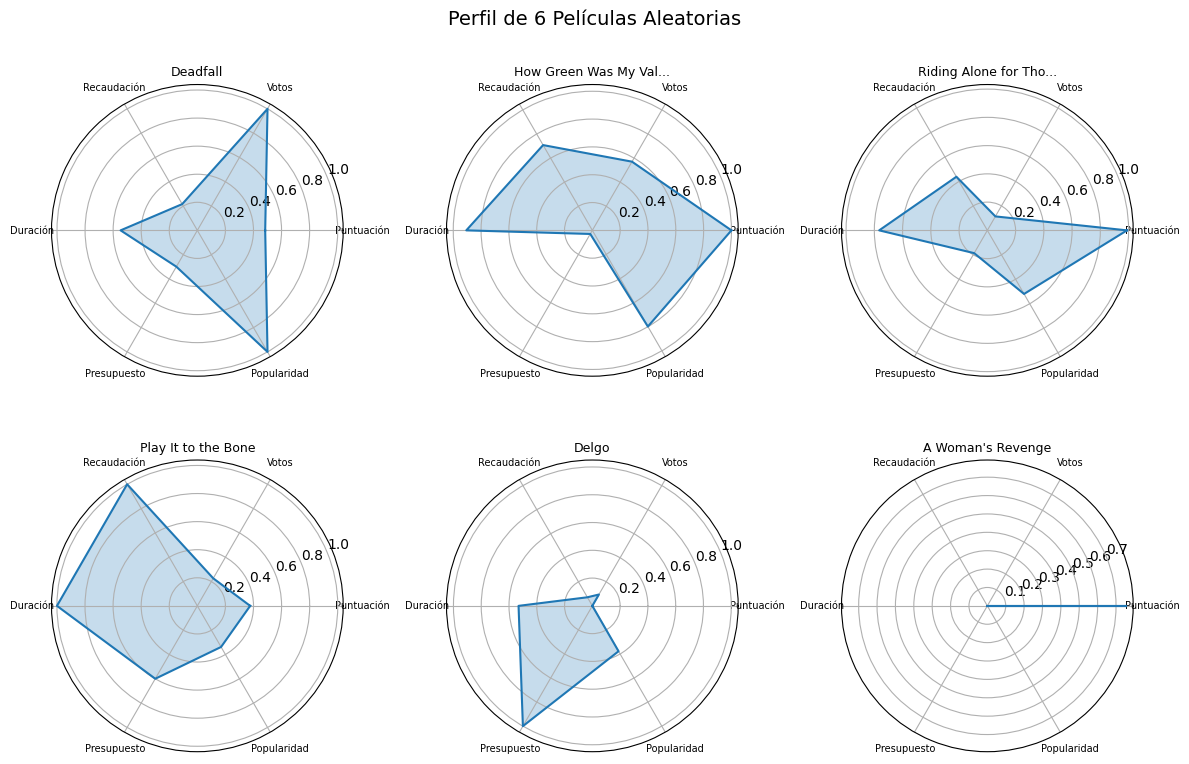

In [ ]:
# Seleccionar 6 películas aleatorias con datos completos
sample_df = df_viz.sample(n=6, replace=False)

# Variables numéricas a usar
variables = ['vote_average', 'vote_count', 'revenue',
             'runtime', 'budget', 'popularity']

# Normalizar datos
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(sample_df[variables])

# Crear etiquetas con el título de la película
labels = [f"{title[:20]}..." if len(title) > 20 else title
          for title in sample_df['title']]

# Configuración radar
num_vars = len(variables)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # cerrar figura

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    values = scaled_values[i].tolist()
    values += values[:1]  # cerrar estrella

    axes[i].plot(angles, values)
    axes[i].fill(angles, values, alpha=0.25)
    axes[i].set_title(labels[i], size=9)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(['Puntuación', 'Votos', 'Recaudación',
                              'Duración', 'Presupuesto', 'Popularidad'], fontsize=7)

plt.suptitle('Perfil de 6 Películas Aleatorias', fontsize=14)
plt.tight_layout()
plt.show()

NO SÉ CÓMO ANALIZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAARLO

## **5. Conclusión**

El dataset de TMDB, aunque cuenta con más de un millón de registros, refleja una realidad típica de la industria cinematográfica: la mayoría de producciones tienen información incompleta y bajo impacto, mientras que una pequeña fracción de grandes producciones concentra la mayor parte de la popularidad, ingresos y participación de usuarios.

En general, se identifican cuatro aspectos clave:

Problemas de completitud: Muchas variables relevantes, especialmente las financieras y textuales (como overview, genres y keywords), presentan una alta proporción de valores faltantes, lo que limita el uso del dataset completo sin un proceso previo de limpieza.

Distribuciones altamente sesgadas: Variables como revenue, budget, vote_count y popularity están fuertemente concentradas en valores bajos o en cero, con unos pocos outliers que elevan significativamente las medias.

Presencia de anomalías: Existen valores inconsistentes (por ejemplo, ingresos o duración negativos, o duraciones extremadamente altas), lo que evidencia la necesidad de un preprocesamiento riguroso antes de cualquier análisis o modelado.

Relaciones interesantes: Mientras que el éxito comercial (revenue) se relaciona fuertemente con budget y vote_count, la calificación promedio (vote_average) muestra poca correlación con el desempeño financiero, lo que sugiere que la calidad percibida no depende necesariamente del éxito económico.

## **6. Objetivo del Dataset**

El objetivo de este dataset es servir como base para desarrollar un sistema de recomendación de películas que ofrezca una experiencia de descubrimiento personalizada, especialmente en situaciones donde no se cuenta con un historial previo del usuario.

El sistema funcionará en dos etapas. Primero, permitirá aplicar filtros básicos sobre el catálogo, como el género y una calificación mínima, para generar una lista inicial alineada con los gustos generales del usuario. Esto ayuda a reducir el número de opciones y a mostrar resultados más relevantes desde el inicio.

En una segunda etapa, una vez que el usuario seleccione una película específica, el sistema activará un modelo de recomendación basado en contenido. A partir de características como los géneros, las palabras clave y la sinopsis, se sugerirán películas similares. De esta manera, aunque no exista información histórica del usuario, el sistema podrá ofrecer recomendaciones coherentes y contextualizadas, facilitando el descubrimiento de nuevos títulos acordes a sus intereses.